# Will an ECG model work somewhere new?
### From other hospitals to young people at an Italian university

Imagine a student who practises with several teachers, then takes an exam written by a new teacher.
Doing well on familiar exercises is useful. Doing well with a new teacher tells us more about whether
the student learned something that travels.

Our ECG model faces a similar question. The Italian university has not provided its data, so we
cannot measure performance there. We can ask a nearby, testable question:

**When we leave an entire source population out of training, does the model still work there?**

We will move from broad evidence to the specific university problem:

1. Understand what our existing sources can tell us.
2. Replay completed experiments on unfamiliar hospitals and source families.
3. Ask whether useful learning is possible with fewer labeled ECGs.
4. Separate good ranking from a practical referral rule.
5. Design the missing tests for young people and, eventually, Italy.

The plots marked **measured** come from completed local experiments. Plots marked **design only**
show how a future experiment would be arranged; they contain no performance results.
This notebook does not train a new model or read reserved test sets.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/ecg-generalization-mpl')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
project = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'AGENTS.md').exists())
sys.path.insert(0, str(project))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from ecg_experiment.eda.generalization import (
    FAMILIES, label_curve, load_evidence, operating_points, paired_gains,
    pilot_curve, provenance, save_aggregate_report, source_counts,
    sph_ranking, transfer_matrix, verify_saved_scores,
)

sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.titlesize': 14, 'figure.dpi': 115})
evidence = load_evidence()
transfer, labels, pilot = (evidence[name] for name in ('transfer', 'labels', 'pilot'))

## 1. Start with the broad question

A random split inside one source asks: *can the model recognise more ECGs from a familiar setting?*
A whole-source holdout asks: *can it cope with a new setting?*
The second is closer to our Italian question.

Here, **source** is the safest word. Some datasets combine hospitals, and related datasets can share
records. We therefore hold out related sources together: Chapman with Ningbo, and CPSC with CPSC-Extra.
These are source-family experiments, rather than a claim that every dataset is one independent hospital.

The picture below describes the completed training comparisons. Each row is a separate fit.

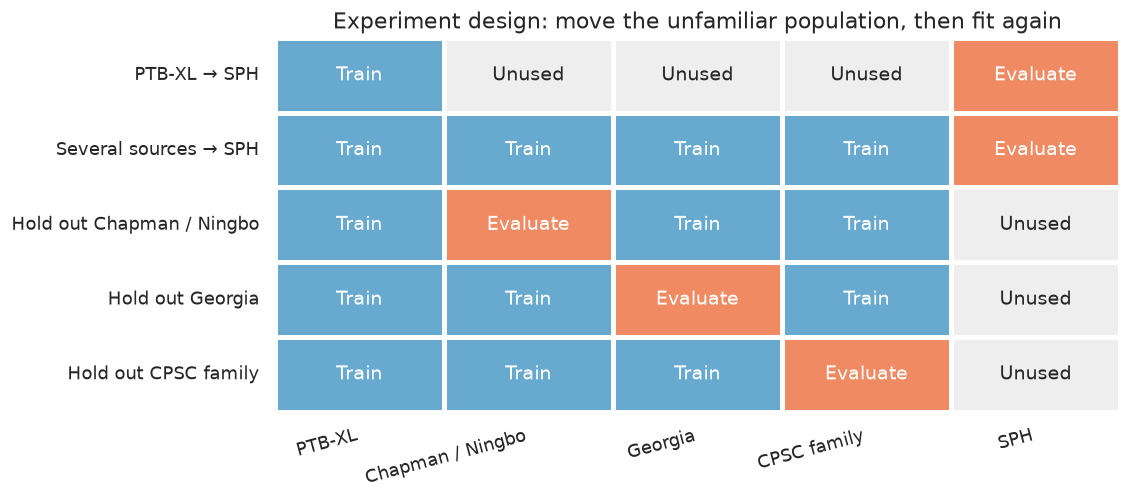

In [2]:
design = pd.DataFrame(
    [[1, 0, 0, 0, 2], [1, 1, 1, 1, 2], [1, 2, 1, 1, 0],
     [1, 1, 2, 1, 0], [1, 1, 1, 2, 0]],
    index=['PTB-XL → SPH', 'Several sources → SPH', 'Hold out Chapman / Ningbo',
           'Hold out Georgia', 'Hold out CPSC family'],
    columns=['PTB-XL', 'Chapman / Ningbo', 'Georgia', 'CPSC family', 'SPH'],
)
annotations = design.replace({0: 'Unused', 1: 'Train', 2: 'Evaluate'})
sns.heatmap(design, annot=annotations, fmt='', cmap=sns.color_palette(
    ['#eeeeee', '#67a9cf', '#ef8a62']), cbar=False, linewidths=2, vmin=0, vmax=2)
plt.title('Experiment design: move the unfamiliar population, then fit again')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

A fair holdout excludes the target from **every learning step**: unlabeled pretraining, labeled fitting,
preprocessing estimates and model selection. Seeing the target's waveforms without labels still counts
as exposure. Choosing a model after seeing target results also weakens the claim of a fresh test.

Keep repeated ECGs from one person together where patient IDs exist. Keep exact duplicates together.
Challenge sources lack patient IDs, so their record splits cannot rule out repeated patients.

### What can each source contribute?

| Data we have | Role in this question | Important limit |
|---|---|---|
| PTB-XL | Human-read training and development labels | Test set evaluated in earlier studies |
| Chapman / Ningbo | One labeled source family | Related sources; duplicate handling matters |
| Georgia | Another labeled source family | Patient IDs are unavailable in the Challenge release |
| CPSC / CPSC-Extra | One labeled source family | CPSC-Extra has no negatives under our binary label |
| SPH | External evaluation, excluded from training | Repeatedly inspected; now development evidence |
| MIMIC-IV-ECG and CODE-15 | Unlabeled pretraining only | No labels for our supervised comparison |
| EchoNext | Separate echo-confirmed disease question | Different outcome; test stays closed |
| Italian university | The eventual target | No data available; no performance estimate |

“All available data” therefore means all **eligible training data**. It does not mean putting the
external evaluation population or reserved test records into training.

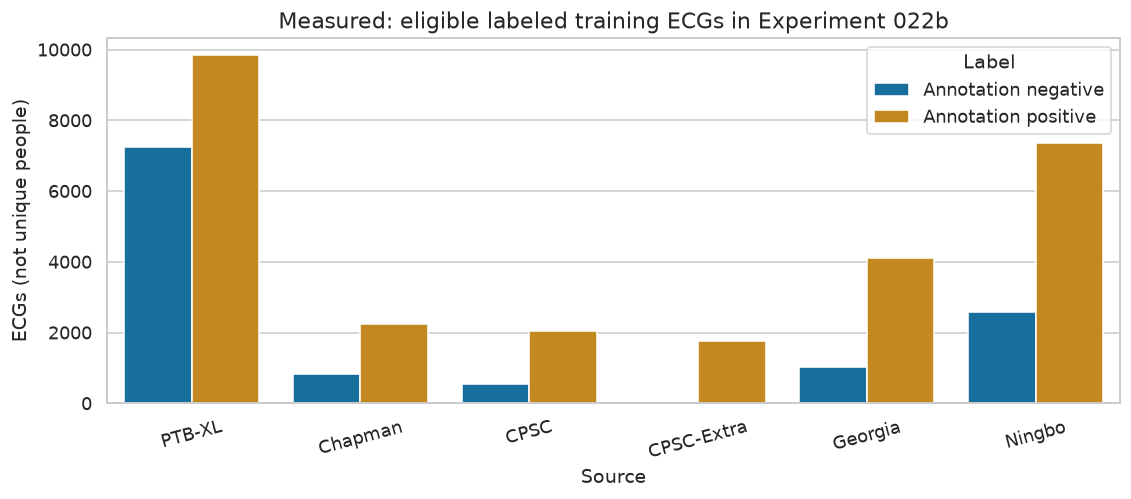

The one-source fit used **17,083 ECGs**; the pooled fit used **39,577 ECGs**. They differ in both source diversity and training size, so this comparison alone cannot tell us which of those two changes caused the gain.

In [3]:
counts = source_counts(transfer)
sns.barplot(data=counts, x='Source', y='ECGs', hue='Label', errorbar=None)
plt.title('Measured: eligible labeled training ECGs in Experiment 022b')
plt.ylabel('ECGs (not unique people)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
display(Markdown(
    f"The one-source fit used **{transfer['counts']['arm_training']['ptbxl']:,} ECGs**; "
    f"the pooled fit used **{transfer['counts']['arm_training']['pooled']:,} ECGs**. "
    "They differ in both source diversity and training size, so this comparison alone cannot "
    "tell us which of those two changes caused the gain."
))

## 2. What does 'works well' mean here?

First we measure **ranking**: do ECGs with abnormal annotations usually receive higher scores than
ECGs with normal annotations? AUROC summarises that ordering. A value of 0.5 is chance ordering;
1.0 is perfect ordering. **0.94 AUROC does not mean 94% accuracy or 94% of cases caught.**

Our outcome is an ECG-annotation proxy. It is not a confirmed cardiopathy diagnosis or a validated
decision that a university student needs referral. Sources also use somewhat different normal labels,
so compare training strategies **within the same evaluation source**, rather than declaring one source
easier or better from its AUROC alone.

Before looking at the results, we check the saved evidence. The next cell verifies the prediction
file's hash and recomputes six SPH AUROCs. It also checks that Experiment 022b reproduced its
predecessor's baseline exactly. Only aggregate values are displayed.

In [4]:
integrity = verify_saved_scores(transfer)
display(integrity.round(6))
display(Markdown('Integrity check passed: all six recomputed AUROCs match their saved results exactly.'))

,Model,Training,Saved AUROC,Recomputed AUROC
0,xECG,ptbxl,0.914868,0.914868
1,xECG,pooled,0.938595,0.938595
2,ECG-JEPA,ptbxl,0.911308,0.911308
3,ECG-JEPA,pooled,0.934263,0.934263
4,CPC,ptbxl,0.875571,0.875571
5,CPC,pooled,0.896950,0.896950


Integrity check passed: all six recomputed AUROCs match their saved results exactly.

## 3. Experiment A: practise on more sources, evaluate on SPH

We reuse three already trained ECG feature extractors, then fit a small classifier on either PTB-XL
alone or the pooled labeled sources. The feature extractors stay fixed. **SPH was absent from labeled
training and from the reported pretraining of all three models.**

This is our clearest existing example of transfer to an unfamiliar source. However, researchers have
now inspected SPH repeatedly. These are historical development results, not a newly untouched final test.

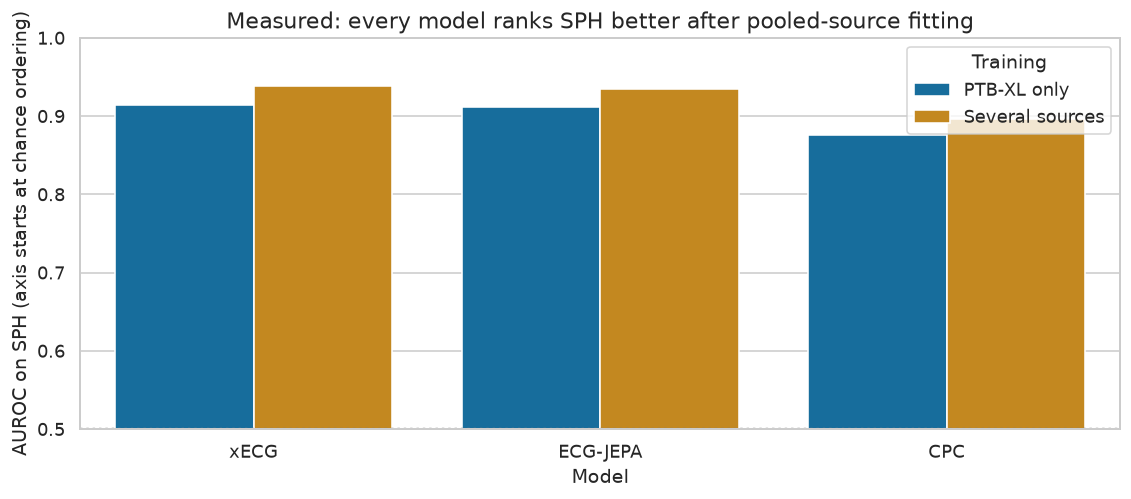

For xECG, ranking rises from **0.915** to **0.939** on the same SPH ECGs. The other two models improve too. This supports transfer across these sources; it does not measure transfer to Italian students.

In [5]:
ranking = sph_ranking(transfer)
sns.barplot(data=ranking, x='Model', y='AUROC', hue='Training', errorbar=None)
plt.ylim(0.5, 1.0)
plt.axhline(0.5, color='gray', linestyle=':')
plt.title('Measured: every model ranks SPH better after pooled-source fitting')
plt.ylabel('AUROC on SPH (axis starts at chance ordering)')
plt.tight_layout()
plt.show()
xecg = ranking[ranking['Model'].eq('xECG')].set_index('Training')['AUROC']
display(Markdown(
    f"For xECG, ranking rises from **{xecg['PTB-XL only']:.3f}** to "
    f"**{xecg['Several sources']:.3f}** on the same SPH ECGs. "
    "The other two models improve too. This supports transfer across these sources; "
    "it does not measure transfer to Italian students."
))

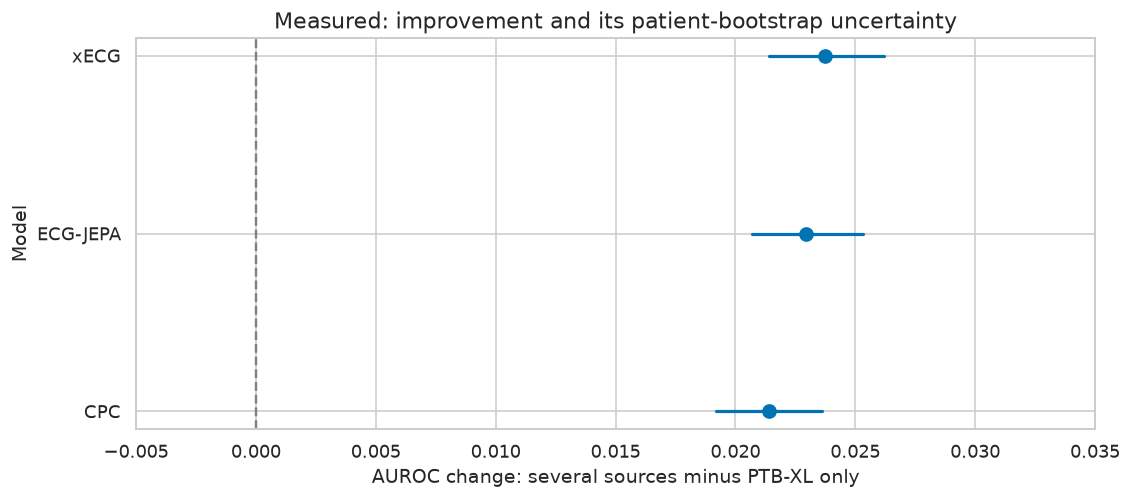

,Model,Gain,Low,High
0,xECG,0.0237,0.0214,0.0262
1,ECG-JEPA,0.0230,0.0207,0.0253
2,CPC,0.0214,0.0192,0.0236


In [6]:
gains = paired_gains(transfer)
sns.scatterplot(data=gains, x='Gain', y='Model', s=100, color=sns.color_palette()[0])
for row in gains.itertuples(index=False):
    plt.plot([row.Low, row.High], [row.Model, row.Model], color=sns.color_palette()[0], linewidth=2)
plt.axvline(0, linestyle='--', color='gray')
plt.xlim(-0.005, 0.035)
plt.title('Measured: improvement and its patient-bootstrap uncertainty')
plt.xlabel('AUROC change: several sources minus PTB-XL only')
plt.tight_layout()
plt.show()
display(gains.round(4))

The lines are saved 95% paired bootstrap intervals: the original experiment repeatedly resampled whole
SPH patients and compared both models on the same draws (2,000 draws, seed 31031).
All three intervals sit above zero. They describe uncertainty for **these fixed models on SPH**;
they do not include training variability or uncertainty about an entirely new Italian population.

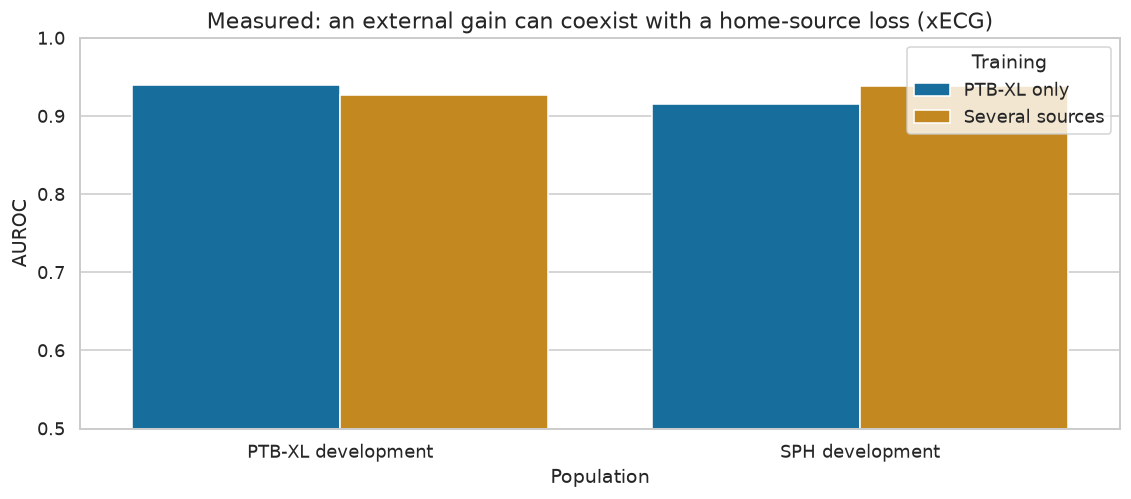

On full PTB-XL development, the same change goes from 0.939 to 0.927. More sources did not improve every population.

In [7]:
home = transfer['ranking']['xecg']['evaluations']['development_full']['metrics']
comparison = pd.DataFrame([
    {'Population': population, 'Training': training, 'AUROC': metrics[arm]['auroc']}
    for population, metrics in [('PTB-XL development', home),
        ('SPH development', transfer['ranking']['xecg']['evaluations']['sph']['metrics'])]
for arm, training in [('ptbxl', 'PTB-XL only'), ('pooled', 'Several sources')]]
)
sns.barplot(data=comparison, x='Population', y='AUROC', hue='Training', errorbar=None)
plt.ylim(0.5, 1)
plt.title('Measured: an external gain can coexist with a home-source loss (xECG)')
plt.tight_layout()
plt.show()
display(Markdown(
    f"On full PTB-XL development, the same change goes from {home['ptbxl']['auroc']:.3f} "
    f"to {home['pooled']['auroc']:.3f}. More sources did not improve every population."
))

## 4. Experiment B: change which source family is unfamiliar

Perhaps SPH is a lucky example. We can repeat the idea by leaving out one Challenge source family at
a time. The middle column below is the important one: the classifier never used that family's labels.
The right column is a familiar-source comparison, because its training rows were included.

These evaluation rows belong to previously used **calibration/development groups**. The reserved
Challenge test groups remain closed.

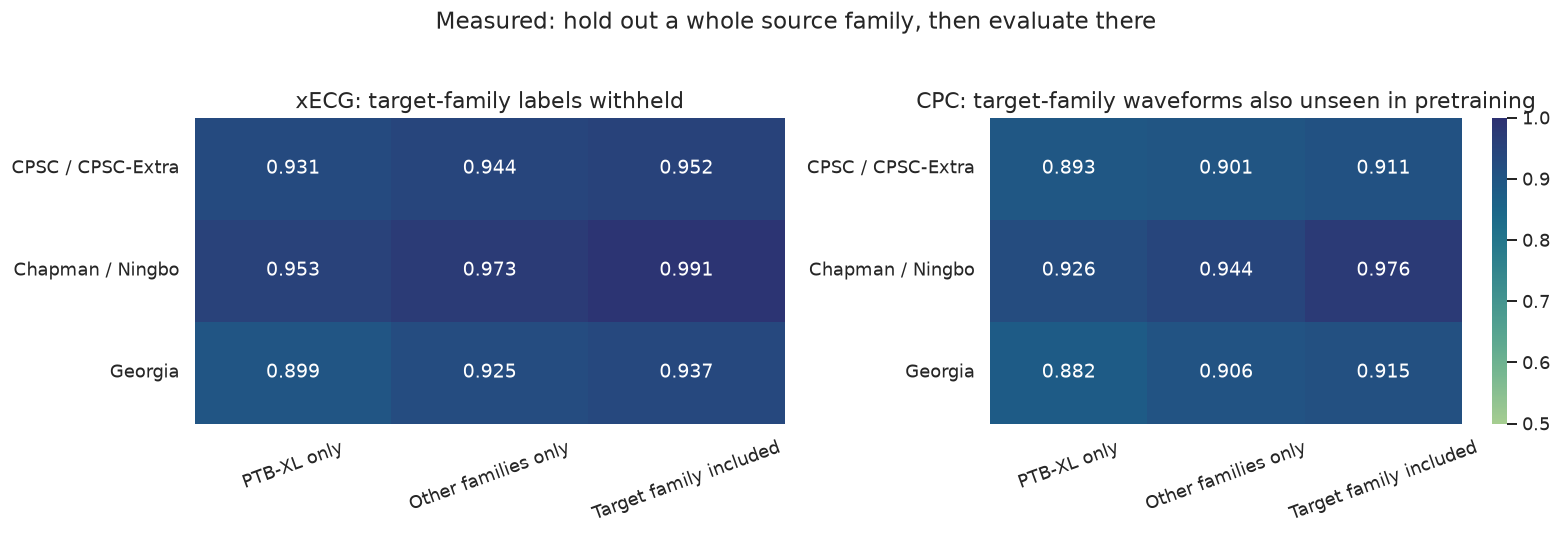

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for encoder, title, ax in [('xecg', 'xECG: target-family labels withheld', axes[0]),
                          ('cpc', 'CPC: target-family waveforms also unseen in pretraining', axes[1])]:
    sns.heatmap(transfer_matrix(transfer, encoder), annot=True, fmt='.3f', vmin=0.5, vmax=1,
                cmap='crest', ax=ax, cbar=encoder == 'cpc')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)
fig.suptitle('Measured: hold out a whole source family, then evaluate there', y=1.03)
plt.tight_layout()
plt.show()

Within each row, using other families usually improves ranking over PTB-XL alone. Including the target
family's own labels improves it further. That remaining gap is one way to see the cost of unfamiliarity.

There is an exposure catch: released xECG and ECG-JEPA report Chapman/Ningbo ECGs in unlabeled
pretraining. Their Chapman/Ningbo result therefore tests an unfamiliar **label source**, rather than
a completely unseen waveform source. CPC did not see Challenge waveforms in pretraining, so its panel
provides the stricter control. We cannot audit every aspect of released-model pretraining here.

Challenge lacks patient IDs. Its original bootstrap is record-based, and familiar-family fits may
benefit from unidentified repeat patients. Do not treat these heatmaps as definitive hospital validation.

## 5. Experiment C: can a small labeled set teach something useful?

Before narrowing to young people, ask a simpler question: what happens when we reduce the number of
labeled training ECGs? Experiment 025b sampled 100 to 4,000 labels, repeated each selection 20 times,
fitted the small classifier and evaluated on SPH. The existing feature extractors stayed fixed.

Both curves below use the **same total label budget** at each point. The pooled curve draws that
budget across eligible sources. It does not secretly add all the other hospitals' labels.

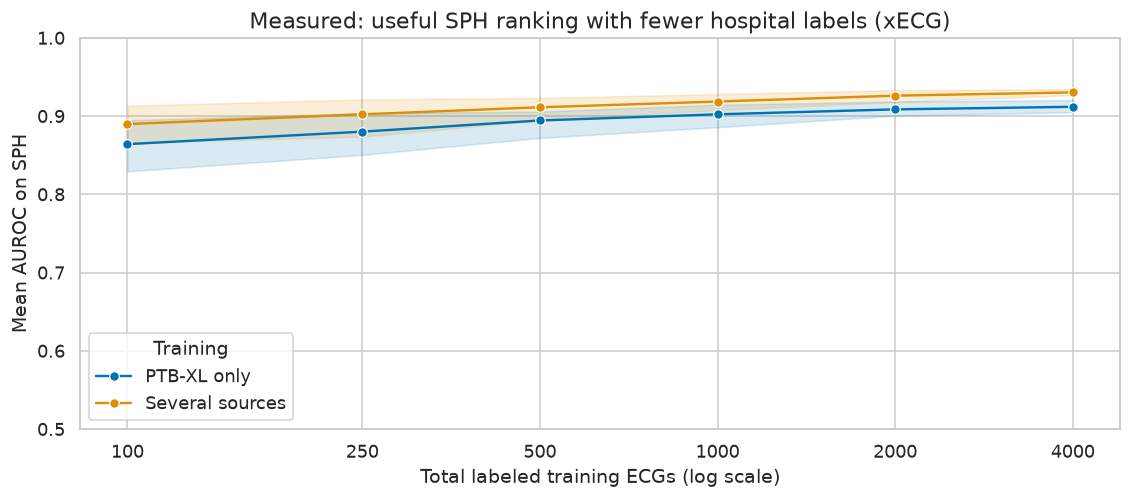

Training,PTB-XL only,Several sources
Labels,,
100,0.864,0.890
250,0.880,0.902
500,0.895,0.911
1000,0.902,0.919
2000,0.909,0.926
4000,0.912,0.930


In [9]:
curve = label_curve(labels)
sns.lineplot(data=curve, x='Labels', y='AUROC', hue='Training', marker='o', errorbar=None)
for (name, group), color in zip(curve.groupby('Training', sort=False), sns.color_palette(), strict=False):
    plt.fill_between(group['Labels'], group['Low'], group['High'], alpha=0.15, color=color)
plt.xscale('log')
plt.xticks(labels['budgets'], labels['budgets'])
plt.ylim(0.5, 1)
plt.title('Measured: useful SPH ranking with fewer hospital labels (xECG)')
plt.xlabel('Total labeled training ECGs (log scale)')
plt.ylabel('Mean AUROC on SPH')
plt.tight_layout()
plt.show()
display(curve.pivot(index='Labels', columns='Training', values='AUROC').round(3))

The bands show the 2.5th to 97.5th percentiles across 20 training-label selections. They describe
selection variability, **not** confidence intervals for Italy. The original study's formal overall
decision was mixed; a higher mean did not satisfy every consistency rule.

This experiment shows that pretrained features can support useful ranking with a smaller labeled
hospital sample. It does **not** show that 100 young-person ECGs would be enough. Those samples can
contain different findings and very few positive cases. Also, this study's PTB-XL pool excludes some
harder records used in Experiment 022b, so its full-pool model is not the identical previous model.

## 6. Get closer to a university: ranking is only half the question

A nurse needs to know which ECGs to send to the cardiologist. That requires a cutoff, not just an order.
A good ordering can coexist with too many false referrals or too many missed abnormal annotations.

The historical comparison below used cutoffs fitted at training sources to aim for at least 95%
sensitivity there. At SPH, pooling improved ranking but changed the balance of missed and referred ECGs.
This historical cutoff is an illustration of transfer failure, **not our university operating rule**.

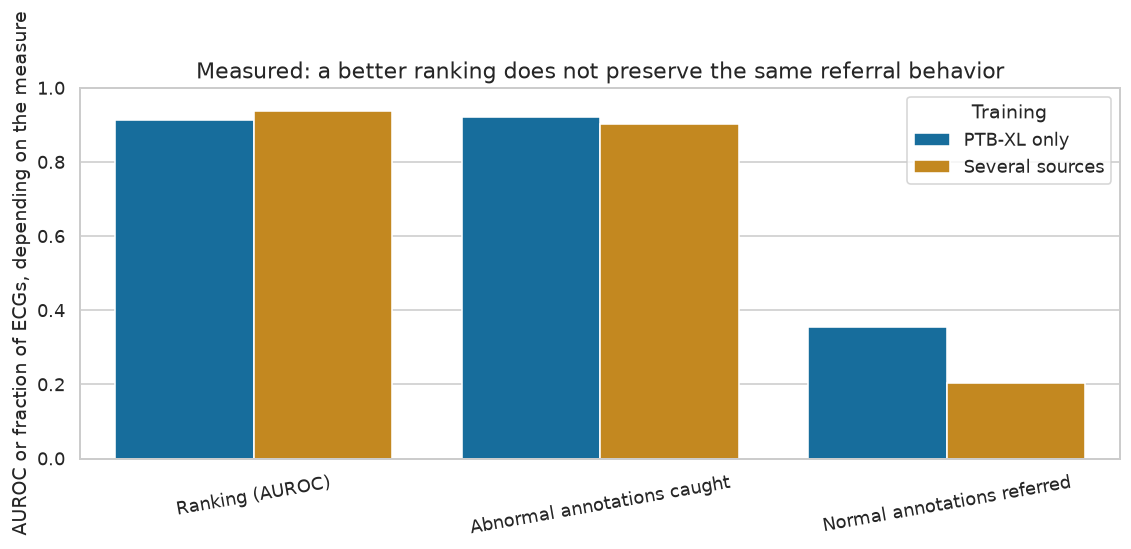

Training,PTB-XL only,Several sources
Measure,,
Abnormal annotations caught,0.922,0.902
Normal annotations referred,0.354,0.203
Ranking (AUROC),0.915,0.939


In [10]:
operating = operating_points(transfer)
sns.barplot(data=operating, x='Measure', y='Value', hue='Training', errorbar=None)
plt.ylim(0, 1)
plt.title('Measured: a better ranking does not preserve the same referral behavior')
plt.ylabel('AUROC or fraction of ECGs, depending on the measure')
plt.xlabel('')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()
display(operating.pivot(index='Measure', columns='Training', values='Value').round(3))

The university approach is to choose a **referral budget among normal ECGs**, then set the cutoff
using a separate local sample that the cardiologist has read as normal. A 5% budget means referring
roughly 5 of every 100 normal ECGs, not guaranteeing that 95% of abnormalities will be caught.

That creates two different questions:

- **No local data:** does the score rank an unfamiliar population usefully?
- **A small local normal pilot:** can we choose a manageable referral cutoff?

The next plot comes from a simulated local pilot at SPH (Experiment 030). Local pilot patients and
evaluation patients were kept separate. This stage intentionally uses some local normal ECGs; it is
not zero-local-data transfer.

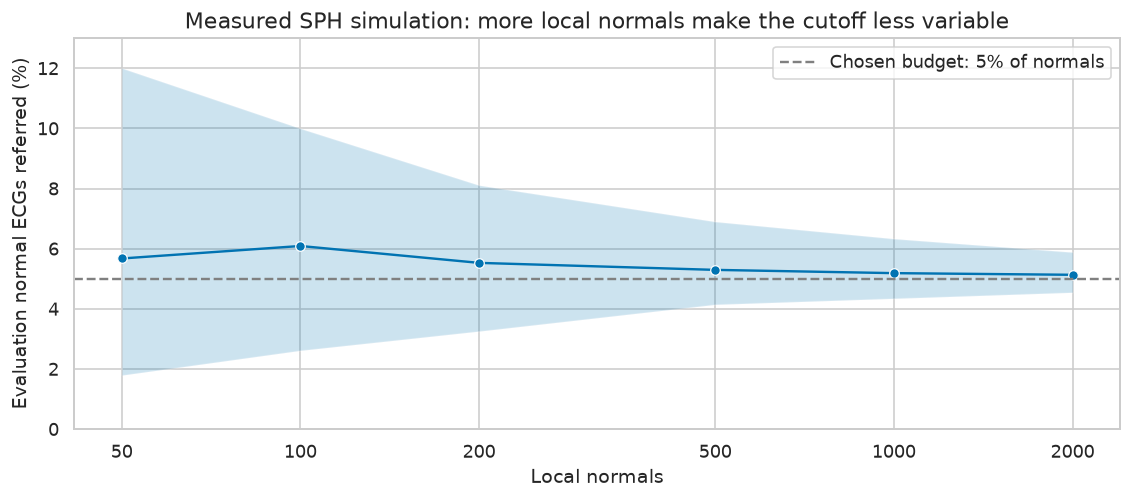

With 200 local normals, the achieved normal-referral rate ranges from **3.3% to 8.1%** across the central 90% of simulated pilots. Mean sensitivity to the binary annotation proxy is **0.775**. These are hospital-development simulations with the historical pooled head, not estimates for young students or a claim about a later pipeline version.

In [11]:
pilot_data = pilot_curve(pilot)
sns.lineplot(data=pilot_data, x='Local normals', y='Mean referral rate (%)', marker='o', errorbar=None)
plt.fill_between(pilot_data['Local normals'], pilot_data['Low'], pilot_data['High'], alpha=0.2)
plt.axhline(5, linestyle='--', color='gray', label='Chosen budget: 5% of normals')
plt.xscale('log')
plt.xticks(pilot_data['Local normals'], pilot_data['Local normals'])
plt.ylim(0, max(pilot_data['High']) + 1)
plt.title('Measured SPH simulation: more local normals make the cutoff less variable')
plt.ylabel('Evaluation normal ECGs referred (%)')
plt.legend()
plt.tight_layout()
plt.show()
p200 = pilot_data[pilot_data['Local normals'].eq(200)].iloc[0]
display(Markdown(
    f"With 200 local normals, the achieved normal-referral rate ranges from "
    f"**{p200['Low']:.1f}% to {p200['High']:.1f}%** across the central 90% of simulated pilots. "
    f"Mean sensitivity to the binary annotation proxy is **{p200['Sensitivity']:.3f}**. "
    "These are hospital-development simulations with the historical pooled head, not estimates "
    "for young students or a claim about a later pipeline version."
))

Here the shaded band is the 5th to 95th percentile across local-pilot draws. It measures how much the
cutoff changes when different normal patients happen to enter the pilot. It is not the patient-bootstrap
interval shown earlier.

Hospitals and universities are different settings. We have not measured the students' distribution
of findings or their positive rate. In a population with few positives, even a modest false-referral rate
can fill much of the cardiologist's workload. Good hospital AUROC alone cannot settle that question.

## 7. Now narrow the question to young people

The broad experiments changed the source. The next experiments would change **age as well as source**.
None of the results above measures that combined change.

The project's youth analysis and student-label definition are pending cardiologist review. This notebook
therefore specifies the experiments below without selecting an age boundary, changing clinical labels,
or reporting a youth score. “Young” must be defined before a run and matched to the intended university
population. Unknown ages need an explicit rule; they must not slip into an “adults only” training arm.

| Next experiment | Training data | Independent evaluation |
|---|---|---|
| All ages → young | Other families, all ages | Young people at a held-out source |
| Adults only → young | Same families, young records removed | Same young evaluation patients |
| Few young labels → young | Adults + small young budget from other families | Same young evaluation |
| Young-only transfer | Young people in training families | Young people at another family |
| Local adaptation | Frozen model + separate local pilot | Remaining local young patients |

For the adults-only stress test, young people must also be excluded from **unlabeled pretraining**.
Filtering only the classifier's labels asks a weaker question. Released checkpoints with uncertain
age exposure cannot establish an age-never-seen claim; a clean cohort and a newly profiled training
run may be required.

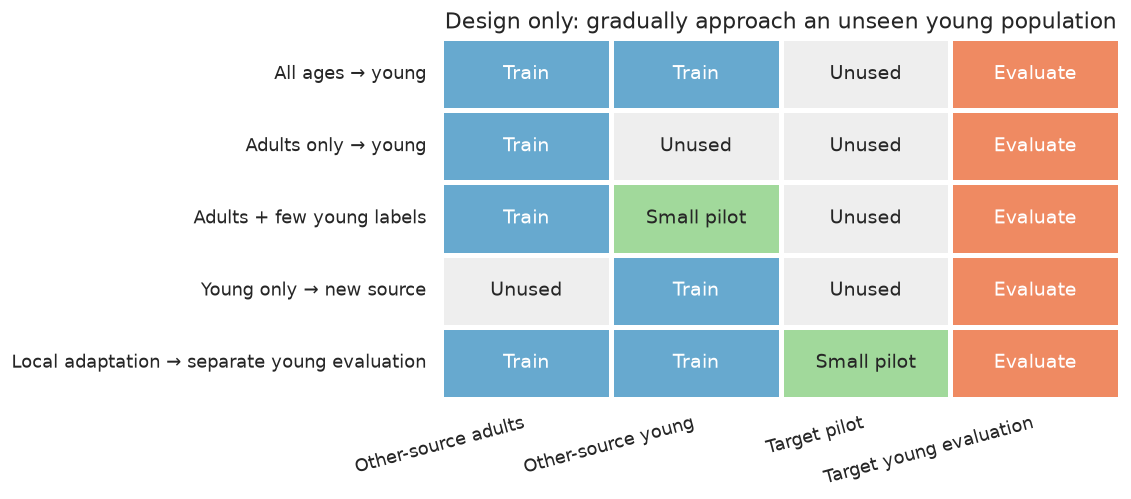

In [12]:
youth_design = pd.DataFrame(
    [[1, 1, 0, 2], [1, 0, 0, 2], [1, 3, 0, 2], [0, 1, 0, 2], [1, 1, 3, 2]],
    index=['All ages → young', 'Adults only → young', 'Adults + few young labels',
           'Young only → new source', 'Local adaptation → separate young evaluation'],
    columns=['Other-source adults', 'Other-source young', 'Target pilot', 'Target young evaluation'],
)
youth_annotations = youth_design.replace({0: 'Unused', 1: 'Train', 2: 'Evaluate', 3: 'Small pilot'})
sns.heatmap(youth_design, annot=youth_annotations,
            fmt='', cmap=sns.color_palette(['#eeeeee', '#67a9cf', '#ef8a62', '#a1d99b']),
            vmin=0, vmax=3, cbar=False, linewidths=2)
plt.title('Design only: gradually approach an unseen young population')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### How would we keep those comparisons fair?

First count usable young positives and negatives in **permitted training/development partitions**,
by source and patient. Count missing ages too. A small number of young positives may make a score too
uncertain to interpret, even if many normal ECGs are available.

Keep one evaluation group fixed across the age arms. Compare both the full-data adult arm and a
size-matched adult sample, so removing young people is not confused with simply removing training data.
Keep fitting budgets matched and preprocessing learned on training data only. Repeat training-label
selections and report how much the answer changes.

For few-young-label learning, choose the budgets after that inventory. Plot mean performance against
the number of young labels added, with patient intervals and selection variability shown separately.
Never choose the best label budget from the final evaluation set. If the target source supplies any pilot
labels, call it adaptation and keep its evaluation patients separate.

SPH stays out of model training in every design. We can use it as a development evaluation population,
but repeated SPH comparisons cannot become a fresh final test. Reserved Challenge and EchoNext tests
stay closed until the approved final evaluation.

Each future run needs a committed protocol, baseline reproduction, a real GPU profile when relevant,
and a results report. No age experiment has been launched by this notebook.

## 8. What confidence does this give us about Italy?

We have measured a useful piece of the argument: models can transfer ranking to SPH and to held-out
source families, and pooled-source fitting improved several comparisons. That makes cross-source
generalization plausible enough to investigate further.

We have not measured the most specific pieces: an age-never-seen model, learning from a few young
ECGs, young people at an unseen university, or the Italian recording setup and labels.
Passing hospital tests adds evidence; it does not give a numerical probability of Italian success.
We cannot turn a 0.939 SPH AUROC into an Italian AUROC.

The evidence becomes closer to our real question at each step, but only the broad steps have results:

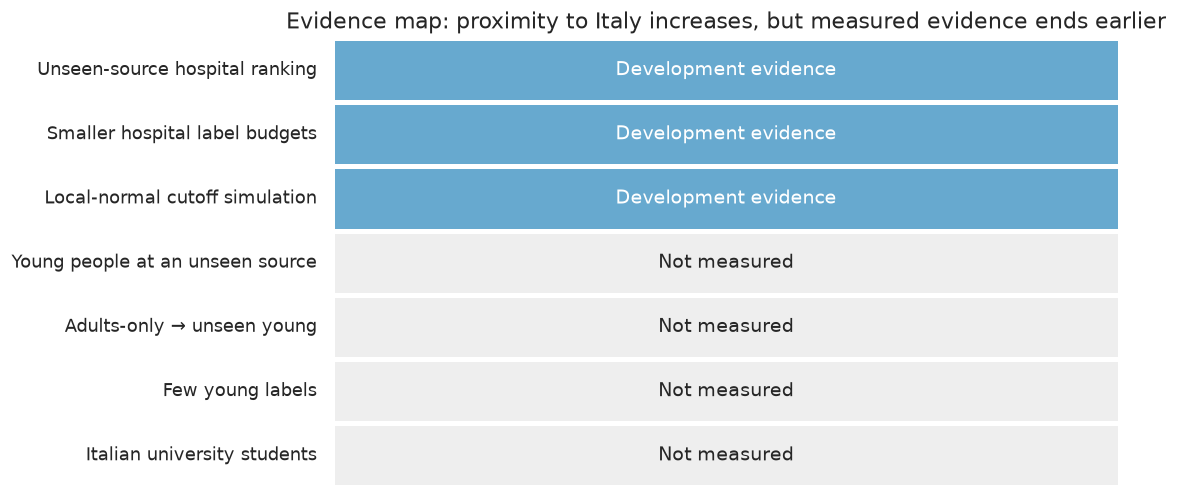

In [13]:
progress = pd.DataFrame({'Question': ['Unseen-source hospital ranking', 'Smaller hospital label budgets',
    'Local-normal cutoff simulation', 'Young people at an unseen source', 'Adults-only → unseen young',
    'Few young labels', 'Italian university students'],
    'Measured': [1, 1, 1, 0, 0, 0, 0]})
status = progress.set_index('Question')
sns.heatmap(status, annot=status.replace({0: 'Not measured', 1: 'Development evidence'}), fmt='',
            cmap=sns.color_palette(['#eeeeee', '#67a9cf']), cbar=False, linewidths=2, vmin=0, vmax=1)
plt.title('Evidence map: proximity to Italy increases, but measured evidence ends earlier')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**A simple way to explain the research:**

> We cannot test the Italian students yet. Instead, we practise the same challenge with the ECG
> sources we already have: learn from some populations and evaluate on a different one. Then we make
> the challenge closer to a university by focusing on young people and limited relevant data.
> Success at each step would give us more evidence that the model has learned useful patterns that
> travel. The final answer still needs independent data from the Italian university.

When Italian data become available, use a separate pilot for any local cutoff or adaptation and keep
independent patients for the evaluation. Report both ranking and referral behavior, along with the
cardiologist-agreed outcome. Until then, Italian performance remains unknown.

## Evidence and reproducibility

This notebook rereads local output files; it contains no invented performance scores. Patient-level
SPH predictions are used only for the integrity check and are never displayed or exported.
No raw credentialed ECGs, Challenge test records, or EchoNext test records are loaded.

- [022b: cross-source fitting and family holdouts](../docs/experiment-022b-multisource-readout-results.md)
- [025b: smaller label budgets](../docs/experiment-025b-label-efficiency-multisource-results.md)
- [030: local-normal referral-budget simulation](../docs/experiment-030-referral-budget-results.md)
- [Audit: prior exposure and limits of the evidence](../docs/audit-2026-09-30.md)
- [Cardiologist meeting: student screening context](../docs/cardiologist-meeting-prep.md)

Build: `uv run --no-sync python -m scripts.reports.build_generalization_notebook`

Execute from the root:

```bash
uv run --no-sync jupyter nbconvert --to notebook --execute --inplace \
  notebooks/11-jr-unseen-populations.ipynb
```

Required local results are listed below. Missing or changed evidence raises an error rather than silently
replacing measured values. The installed development environment already includes Seaborn and Jupyter.

In [14]:
display(provenance())
save_aggregate_report(evidence, project / 'outputs/eda/generalization/aggregate_report.json')
display(Markdown('Saved aggregate verification and provenance to '
                 '`outputs/eda/generalization/aggregate_report.json`.'))

,Evidence,File,SHA-256
0,transfer,outputs/experiment022b_multisource_readout_v1/...,217e866340071e66844bcdfd4bc3700bee151f1e329cf5...
1,labels,outputs/experiment025b_label_efficiency_multis...,8c28968dd70518fd234118965903af22c478e1c09a1f07...
2,pilot,outputs/experiment030_referral_budget_v1/resul...,b20c7b1c26e2e5af307bee236fcad62b2ec241bafbcd84...


Saved aggregate verification and provenance to `outputs/eda/generalization/aggregate_report.json`.